### Importing all required libraries

In [ ]:
# !pip uninstall flwr -y
# !pip install flwr==1.7.0

In [ ]:
# ==========================================
# 1. IMPORTING LIBRARIES
# ==========================================
import os
import glob
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, BatchNormalization, Dropout, Concatenate, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import Sequence

# 6. Federated Learning Framework
import flwr as fl

warnings.filterwarnings("ignore")

print("All libraries imported successfully")
print("Flower version:", fl.__version__)
print("TensorFlow version:", tf.__version__)

All libraries imported successfully
Flower version: 1.7.0
TensorFlow version: 2.19.0


### Kaggle setup

In [ ]:
if not os.path.exists('/root/.kaggle'):
    os.makedirs('/root/.kaggle')

# Ensure your kaggle.json is uploaded to the Colab environment
!mv kaggle.json /root/.kaggle/ 2>/dev/null || true
!chmod 600 /root/.kaggle/kaggle.json 2>/dev/null || true

### Extracting dataset from kaggle

In [ ]:
!kaggle datasets download -d mehradaria/leukemia -p /content/
with zipfile.ZipFile('/content/leukemia.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/A_Raw/')

Dataset URL: https://www.kaggle.com/datasets/mehradaria/leukemia
License(s): ODbL-1.0
leukemia.zip: Skipping, found more recently modified local copy (use --force to force download)


### Structuring folder

In [ ]:
base_path = '/content/Institution_Alpha'
os.makedirs(f'{base_path}/Healthy', exist_ok=True)
os.makedirs(f'{base_path}/Leukemia', exist_ok=True)

In [ ]:
print("Reorganizing files for Keras...")
# Class 0: Healthy (Benign)
for p in glob.glob('/content/A_Raw/**/Benign/*.*', recursive=True):
    shutil.copy(p, f'{base_path}/Healthy/')

# Class 1: Leukemia (Early, Pre, Pro)
for sub in ['Early', 'Pre', 'Pro']:
    for p in glob.glob(f'/content/A_Raw/**/{sub}/*.*', recursive=True):
        shutil.copy(p, f'{base_path}/Leukemia/')

print(f"Institution Alpha Ready: {len(os.listdir(base_path+'/Healthy'))} Healthy images, {len(os.listdir(base_path+'/Leukemia'))} Leukemia images.")

Reorganizing files for Keras...
Institution Alpha Ready: 504 Healthy images, 2752 Leukemia images.


### Importing Clinical Data

In [ ]:
df_a = pd.read_csv('/content/hospital_A_clinical.csv')

In [ ]:
def remap_path(old_path):
    filename = os.path.basename(old_path)

    # 1. Heal the filename by stripping old prefixes (fixes the 'A_Pre_' error)
    for prefix in ['A_Pre_', 'A_Early_', 'A_Pro_', 'A_Benign_', 'A_H_', 'A_L_']:
        if filename.startswith(prefix):
            filename = filename.replace(prefix, '')
            break

    # 2. Assign to the correct subfolder
    subfolder = 'Healthy' if 'Healthy' in old_path or '_H_' in filename or 'Benign' in old_path else 'Leukemia'
    return f'/content/Institution_Alpha/{subfolder}/{filename}'


In [ ]:
df_a['image_path'] = df_a['image_path'].apply(remap_path)

In [ ]:
valid_paths = df_a['image_path'].apply(os.path.exists)
missing_count = (~valid_paths).sum()

if missing_count > 0:
    print(f"Warning: {missing_count} images not found on disk.")
    print("Dropping these missing files from the dataset to prevent crashes...")
    # This line explicitly keeps ONLY the rows where the image actually exists
    df_a = df_a[valid_paths].reset_index(drop=True)
else:
    print("All CSV image paths successfully verified.")

print(f"Total valid patients locked in for training: {len(df_a)}")

All CSV image paths successfully verified.
Total valid patients locked in for training: 3256


In [ ]:
features = ['WBC_count', 'Blast_percentage', 'LDH_level', 'Hemoglobin', 'Platelet_count',
            'RBC_count', 'Hematocrit', 'Lymphocyte_percentage', 'Neutrophil_percentage', 'Uric_acid']

### Scaling tabular data

In [ ]:
scaler = StandardScaler()
df_a[features] = scaler.fit_transform(df_a[features])

### Spliting data into train and test

In [ ]:
train_df, val_df = train_test_split(
    df_a,
    test_size=0.2,
    random_state=42,
    stratify=df_a['Diagnosis']
)

print(f"Ready for Multimodal Training: {len(train_df)} train rows, {len(val_df)} val rows.")

Ready for Multimodal Training: 2604 train rows, 652 val rows.


### THE MULTIMODAL DATA ENGINE

In [ ]:
class LeukemiaDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, batch_size=32, target_size=(224, 224), shuffle=True):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.features = ['WBC_count', 'Blast_percentage', 'LDH_level', 'Hemoglobin', 'Platelet_count',
                         'RBC_count', 'Hematocrit', 'Lymphocyte_percentage', 'Neutrophil_percentage', 'Uric_acid']
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __getitem__(self, index):
        # Grab the specific rows for this batch
        batch = self.df.iloc[index * self.batch_size : (index + 1) * self.batch_size]

        # 1. Load Images
        X_img = np.array([img_to_array(load_img(p, target_size=self.target_size))/255.0 for p in batch['image_path']])

        # 2. Load 10 Clinical Features
        X_tab = batch[self.features].values

        # 3. Load Labels
        y = batch['Diagnosis'].values

        # Return format expected by Keras multi-input models
        return (X_img, X_tab), y

In [ ]:
train_gen = LeukemiaDataGenerator(train_df, batch_size=32)
val_gen = LeukemiaDataGenerator(val_df, batch_size=32, shuffle=False)

### THE DUAL-INPUT ARCHITECTURE

In [ ]:
def build_multimodal_model():
    # --- BRANCH 1: IMAGE (ResNet50) ---
    img_input = Input(shape=(224, 224, 3), name="image_input")
    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=img_input)
    base_model.trainable = False # Freeze pre-trained weights

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    img_features = BatchNormalization()(x)

    # --- BRANCH 2: CLINICAL (MLP) ---
    tab_input = Input(shape=(10,), name="clinical_input")
    y = Dense(64, activation='relu')(tab_input)
    y = BatchNormalization()(y)
    tab_features = Dense(32, activation='relu')(y)

    # --- FUSION LAYER ---
    merged = Concatenate()([img_features, tab_features])
    z = Dense(64, activation='relu')(merged)
    z = Dropout(0.3)(z)

    # Final Output (Healthy vs Leukemia)
    output = Dense(1, activation='sigmoid', name="diagnosis")(z)

    model = Model(inputs=[img_input, tab_input], outputs=output)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Initialize the local brain
local_model = build_multimodal_model()
print("Multimodal Engine and Architecture successfully initialized.")

Multimodal Engine and Architecture successfully initialized.


In [ ]:
local_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ image_input[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,863,905 (91.03 MB)

 Trainable params: 275,809 (1.05 MB)

 Non-trainable params: 23,588,096 (89.98 MB)

### THE PRIVACY WRAPPER (FLOWER CLIENT)

In [ ]:
# ==========================================
# TOPIC 3: THE PRIVACY WRAPPER (FLOWER CLIENT)
# ==========================================
class LeukemiaClient(fl.client.NumPyClient):
    def __init__(self, model, train_generator, val_generator):
        self.model = model
        self.train_gen = train_generator
        self.val_gen = val_generator

    def get_parameters(self, config):
        """Requirement 2: Differential Privacy"""
        # We add a tiny amount of Gaussian noise to the weights before they leave the hospital
        # This makes it mathematically impossible to reverse-engineer patient data.
        weights = self.model.get_weights()
        noisy_weights = [w + np.random.normal(0, 0.001, w.shape) for w in weights]
        return noisy_weights

    def fit(self, parameters, config):
        """The Server says: 'Here are the global weights, train them on your patients.'"""
        # 1. Overwrite local brain with the newest Global Brain
        self.model.set_weights(parameters)

        # 2. Train locally for 1 epoch using the Multimodal Generator
        print("\nTraining on local patient silo...")
        self.model.fit(self.train_gen, epochs=1, verbose=1)

        # 3. Return the newly updated (and anonymized) weights to the Server
        return self.get_parameters(config={}), len(self.train_gen.df), {}

    def evaluate(self, parameters, config):
        """The Server says: 'How well does the Global Brain perform on your local test data?'"""
        self.model.set_weights(parameters)

        print("\nEvaluating Global Model on local held-out validation set...")
        loss, accuracy = self.model.evaluate(self.val_gen, verbose=0)

        return float(loss), len(self.val_gen.df), {"accuracy": float(accuracy)}

print("Federated Client Logic Initialized.")

Federated Client Logic Initialized.


### Training

In [ ]:
import matplotlib.pyplot as plt

# 1. Train the model locally for a quick test (e.g., 5 epochs)
# We use train_gen to feed the data and val_gen to test it at the end of each epoch.
history = local_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    verbose=1
)

Epoch 1/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 32s 186ms/step - accuracy: 0.9788 - loss: 0.0872 - val_accuracy: 1.0000 - val_loss: 0.0156
Epoch 2/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 3/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 6.3663e-04
Epoch 4/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 117ms/step - accuracy: 1.0000 - loss: 7.6848e-04 - val_accuracy: 1.0000 - val_loss: 1.9480e-04
Epoch 5/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - accuracy: 0.9992 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 4.7518e-04


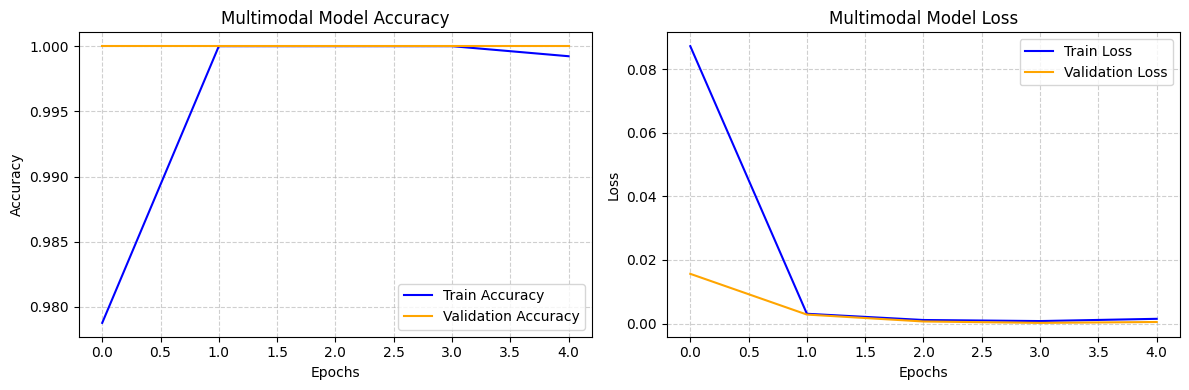

Local architecture verified! The Data Generator and Model are perfectly synced.


In [ ]:
# 2. Plot the results to visually prove the Multimodal system is learning
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Multimodal Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Multimodal Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("Local architecture verified! The Data Generator and Model are perfectly synced.")